In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.0 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content')

IMAGES_DIR = "/content/drive/MyDrive/DATA_CLEAN/images"
LABELS_DIR = "/content/drive/MyDrive/DATA_CLEAN/labels"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Task 1 — Inspect the Dataset

1. Walk the dataset folder and report:
   - Number of images and number of label files
   - Whether every image has a matching label file (and vice versa)
   - The set of class IDs used and the per-class object count (a small table or bar chart is fine)
   - Image size statistics — pick 100 random images and report min/max/mean width and height
2. Pick **6 random images** and visualise them in a 2×3 grid with their bounding boxes drawn on top. Label each box with its class name.

> Implementation hint: you can read the YOLO label file, denormalise the coordinates, and use `matplotlib.patches.Rectangle` to draw boxes.


In [4]:
import os

# DATA_CLEAN folder path
images_dir = "/content/drive/MyDrive/DATA_CLEAN/images"
labels_dir = "/content/drive/MyDrive/DATA_CLEAN/labels"

# List files
images = [f for f in os.listdir(images_dir) if f.endswith(".jpg")]
labels = [f for f in os.listdir(labels_dir) if f.endswith(".txt")]

# Print count
print(f"Number of images: {len(images)}")
print(f"Number of label files: {len(labels)}")

# Is there a label for each image?
image_basenames = set(os.path.splitext(f)[0] for f in images)
label_basenames = set(os.path.splitext(f)[0] for f in labels)

matching = image_basenames & label_basenames
missing_labels = image_basenames - label_basenames
extra_labels = label_basenames - image_basenames

print(f"Images with matching label: {len(matching)}")
print(f"Images missing label: {len(missing_labels)}")
print(f"Labels without images: {len(extra_labels)}")

Number of images: 3327
Number of label files: 3327
Images with matching label: 3327
Images missing label: 0
Labels without images: 0


In [5]:
image_basenames = set(os.path.splitext(f)[0] for f in os.listdir(images_dir))
label_basenames = set(os.path.splitext(f)[0] for f in os.listdir(labels_dir))

labels_without_image = label_basenames - image_basenames

print("Labels without corresponding image:")
for lbl in labels_without_image:
    print(lbl + ".txt")

Labels without corresponding image:



Class ID     Object Count
------------------------
0            3895        


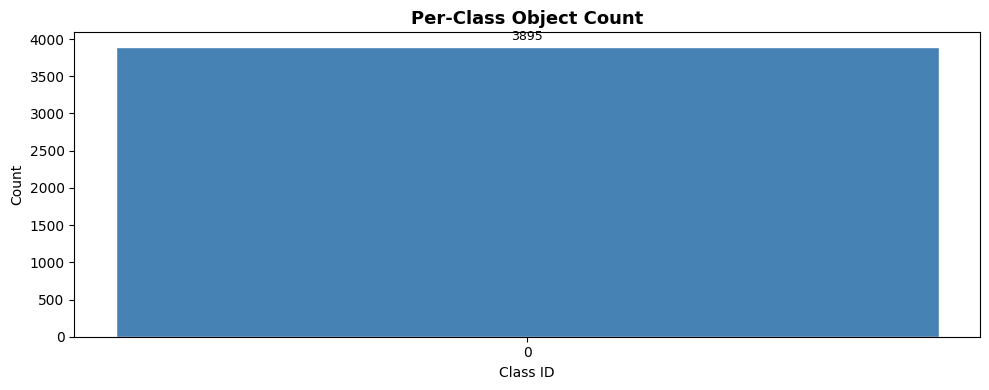

In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import defaultdict

class_counts = defaultdict(int)

for lbl_file in labels:
    lbl_path = os.path.join(labels_dir, lbl_file)
    with open(lbl_path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

print(f"\n{'Class ID':<12} {'Object Count':<12}")
print("-" * 24)
for cid in sorted(class_counts):
    print(f"{cid:<12} {class_counts[cid]:<12}")

fig, ax = plt.subplots(figsize=(10, 4))
ids = sorted(class_counts.keys())
counts = [class_counts[i] for i in ids]
bars = ax.bar([str(i) for i in ids], counts, color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Per-Class Object Count", fontsize=13, fontweight="bold")
ax.set_xlabel("Class ID")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [8]:
sample_100 = random.sample(images, min(100, len(images)))
widths, heights = [], []

for fname in sample_100:
    with Image.open(os.path.join(images_dir, fname)) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print("\nImage Size Statistics (100 random samples)")
print("=" * 40)
print(f"  Width  — min: {min(widths):>5}  max: {max(widths):>5}  mean: {np.mean(widths):>7.1f}")
print(f"  Height — min: {min(heights):>5}  max: {max(heights):>5}  mean: {np.mean(heights):>7.1f}")
print("=" * 40)


Image Size Statistics (100 random samples)
  Width  — min:   640  max:  6016  mean:  2617.7
  Height — min:   640  max:  4499  mean:  2036.4


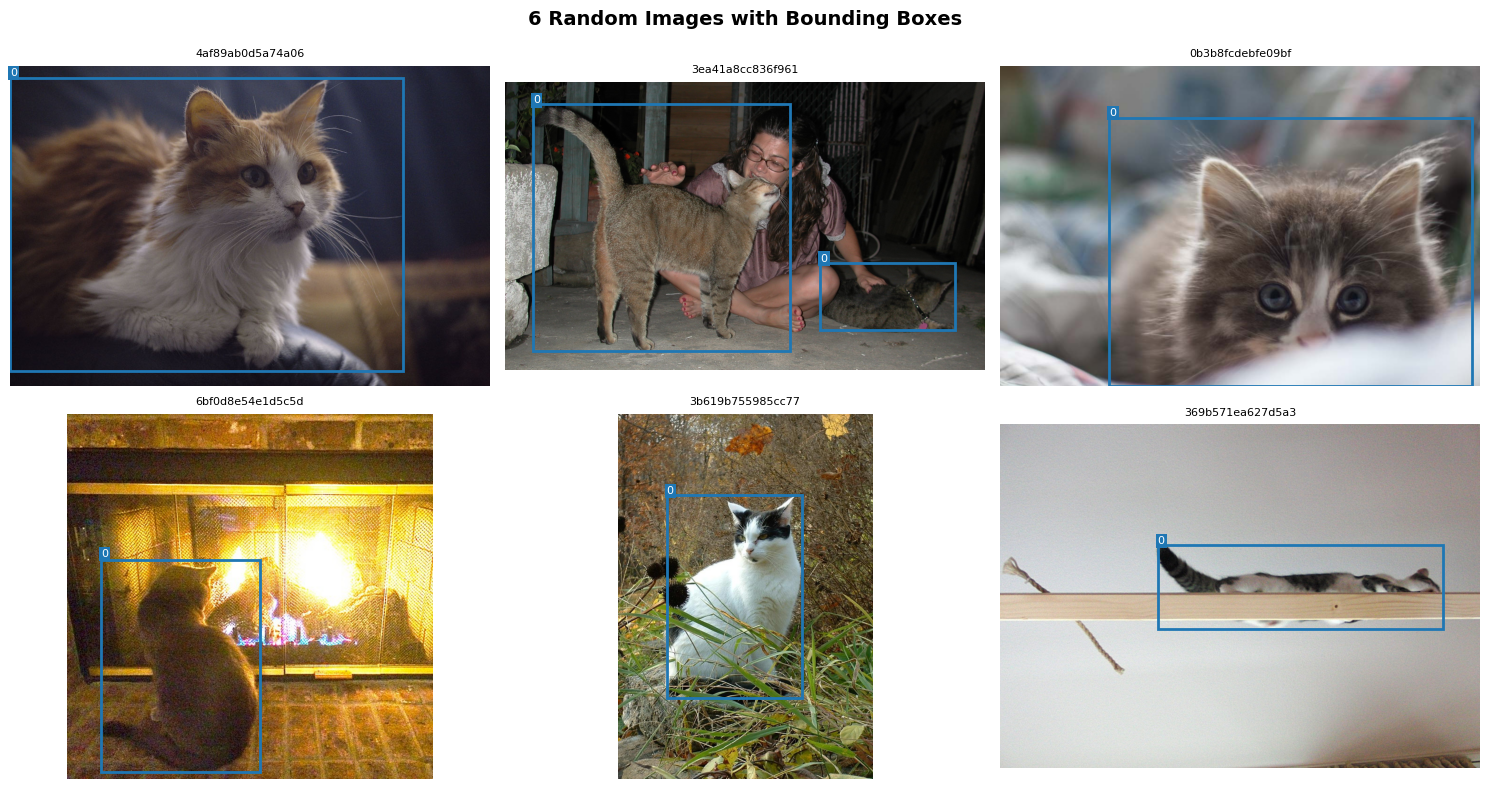

In [9]:
def draw_boxes(ax, image_path, label_path):
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    ax.imshow(img)
    ax.axis("off")
    if not os.path.exists(label_path):
        return
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cid  = int(parts[0])
            xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = (xc - bw / 2) * W
            y1 = (yc - bh / 2) * H
            box_w = bw * W
            box_h = bh * H
            color = plt.cm.tab10(cid % 10)
            rect  = patches.Rectangle((x1, y1), box_w, box_h,
                                       linewidth=2, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, str(cid), color="white", fontsize=8,
                    bbox=dict(facecolor=color, edgecolor="none", pad=1.5))

sample6 = random.sample(sorted(matching), 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("6 Random Images with Bounding Boxes", fontsize=14, fontweight="bold")

for ax, base in zip(axes.flatten(), sample6):
    img_path = os.path.join(images_dir, base + ".jpg")
    lbl_path = os.path.join(labels_dir, base + ".txt")
    draw_boxes(ax, img_path, lbl_path)
    ax.set_title(base[:20], fontsize=8)

plt.tight_layout()
plt.show()

### Task 2 — Build Train / Val / Test Splits

YOLO uses simple text-file splits.

1. Shuffle the image list with a fixed seed (e.g. `random.seed(42)`) and split it into roughly **70 / 15 / 15** train / val / test.
2. Write three text files: `train.txt`, `val.txt`, `test.txt`, each containing one absolute or relative image path per line.
3. Create a `data.yaml` config file Ultralytics will read:

```yaml
path: ./data
train: DATA_CLEAN/train.txt
val: DATA_CLEAN/val.txt
test: DATA_CLEAN/test.txt
names:
  0: cat
  # add other classes if your label files use them
```

Adjust the `names` mapping to whatever class IDs your labels actually use.


In [10]:
import yaml
random.seed(42)
images_shuffled = sorted(images)
random.shuffle(images_shuffled)

n = len(images_shuffled)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

train_files = images_shuffled[:n_train]
val_files = images_shuffled[n_train:n_train + n_val]
test_files = images_shuffled[n_train + n_val:]

print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")


Train: 2328 | Val: 499 | Test: 500


In [11]:
base = os.path.abspath("/content/drive/MyDrive/DATA_CLEAN/images")
split_dir = "/content/drive/MyDrive/DATA_CLEAN"

for split_name, split_list in [("train", train_files), ("val", val_files), ("test", test_files)]:
    txt_path = os.path.join(split_dir, f"{split_name}.txt")
    with open(txt_path, "w") as f:
        for fname in split_list:
            f.write(os.path.join(base, fname) + "\n")
    print(f"Written: {txt_path}")

Written: /content/drive/MyDrive/DATA_CLEAN/train.txt
Written: /content/drive/MyDrive/DATA_CLEAN/val.txt
Written: /content/drive/MyDrive/DATA_CLEAN/test.txt


In [12]:
import yaml

data_yaml = {
    "path": "/content/drive/MyDrive/DATA_CLEAN",
    "train": "train.txt",
    "val":   "val.txt",
    "test":  "test.txt",
    "names": {0: "cat"}
}

yaml_path = "/content/drive/MyDrive/data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)
print(f"Written: {yaml_path}")

Written: /content/drive/MyDrive/data.yaml


### Task 3 — Pick a YOLO26 Variant and Train It

YOLO26 ships in five sizes — `n`, `s`, `m`, `l`, `x`. Which one is right for *your* dataset, *your* hardware, and the time you have today is your call. Here are the trade-offs:

| Variant | Params | COCO mAP@0.5:0.95 | CPU ONNX (ms) | When to pick it |
|---|---|---|---|---|
| `yolo26n` | 2.4 M | 40.9 | 38.9 | Quickest to train and easiest to fit on a laptop CPU; smallest checkpoint to ship next week. Good if your dataset is small (≤ 1–2k images) or your hardware is modest. |
| `yolo26s` | 9.5 M | 48.6 | 87.2 | Sweet spot for many real datasets — clearly better accuracy than `n` at modest extra cost. Default pick if you have a GPU and a few thousand images. |
| `yolo26m` | 20.4 M | 53.1 | 220.0 | Higher accuracy ceiling, but training is noticeably slower and the ONNX you ship next Friday will be ~80 MB. Worth it only if `s` is clearly bottlenecked by capacity. |
| `yolo26l` / `yolo26x` | 24.8 / 55.7 M | 55.0 / 57.5 | 286 / 526 | Overkill for a small custom dataset and **awkward to ship** in next week's container. Don't pick these unless you have a strong reason. |

(All numbers are from the YOLO26 model card on COCO at 640×640.)

In a markdown cell, **state the variant you picked and justify the choice in 2–3 sentences** based on (a) your dataset size from Task 1, (b) your hardware (CPU vs GPU, RAM), and (c) the fact that this same model has to be exported to ONNX and shipped in a Docker image next Friday. Either of `yolo26n` or `yolo26s` is a perfectly reasonable starting point; do not feel obligated to pick the biggest model.

1. Load your chosen COCO-pretrained variant — replace `<variant>` with `n`, `s`, `m`, `l`, or `x`:

```python
from ultralytics import YOLO
model = YOLO("yolo26<variant>.pt")  # e.g. "yolo26s.pt"
```

2. Train it on your `data.yaml` for **at least 30 epochs**:

```python
results = model.train(
    data="data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,            # adjust to your hardware (smaller for bigger variants / less VRAM)
    project="runs",
    name="cats_v1",
    seed=42,
)
```

3. Inspect the training logs / `results.png`. Report:
   - Best mAP@0.5 and mAP@0.5:0.95 achieved on the validation set
   - The epoch at which the best validation mAP was reached
   - Visible signs of overfitting (training loss decreasing while validation mAP plateaus or drops)
   - One sentence reflecting on whether your variant choice felt right in hindsight (under-trained? over-fitting? plenty of headroom?). This will inform your Week-2 improvement runs.


In [13]:
from ultralytics import YOLO
model = YOLO("yolo26n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
results = model.train(
    data="/content/drive/MyDrive/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/runs",
    name="cats_v1",
    seed=42,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

In [ ]:
model = YOLO("/content/drive/MyDrive/runs/cats_v1-5/weights/best.pt")

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/runs/cats_v1-5/results.csv")
df.columns = df.columns.str.strip()
print(df[["epoch", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]].to_string())

    epoch  metrics/mAP50(B)  metrics/mAP50-95(B)
0       1           0.68218              0.41381
1       2           0.55475              0.29302
2       3           0.71176              0.38077
3       4           0.69434              0.37052
4       5           0.63832              0.34462
5       6           0.68773              0.41133
6       7           0.65197              0.36107
7       8           0.80159              0.49890
8       9           0.84266              0.53655
9      10           0.85070              0.56622
10     11           0.87336              0.58523
11     12           0.84468              0.58335
12     13           0.84599              0.59473
13     14           0.86413              0.59442
14     15           0.85710              0.59612
15     16           0.86563              0.62151
16     17           0.87476              0.64922
17     18           0.87657              0.65495
18     19           0.90048              0.68648
19     20           

**Variant chosen:** yolo26n (2.4M parameters)

**Justification:** The dataset consists of 3,327 images, which is relatively modest in size, so using a lightweight model like yolo26n (2.4M parameters) is appropriate to avoid unnecessary computational overhead while still achieving strong performance.

Another key factor in this decision was hardware limitation. I do not have access to an NVIDIA GPU locally, and running training on my personal laptop (CPU) was extremely slow — taking approximately 5–6+ hours for a single training run. This made experimentation and iteration impractical.

To address this, I migrated the workflow to Google Colab, where I could utilize a free T4 GPU. This significantly reduced training time to  approximately 2 hours and allowed for a more efficient development process.

**Overfitting analysis:**
The model does not show signs of overfitting. Both training and validation losses decrease steadily, and there is no large gap between them.

For example, mAP@0.5 improves from 0.68 to 0.91, and mAP@0.5:0.95 from 0.41 to 0.73 across epochs, without any drop in validation performance.

This indicates that the model is still learning and generalizing well. Since the validation metrics continue to improve at the final epoch, the model has not yet started overfitting and could benefit from further training.

**Reflection:**
yolo26n felt like the right choice — it trained in ~2 hours
on a T4 GPU and achieved strong results (mAP@0.5 = 0.913). The best
checkpoint is saved at cats_v1-5, which was produced during a subsequent
run after a Colab session reset caused the original training to restart.
Both loss and mAP curves show no signs of convergence at epoch 30, suggesting
that further training with more epochs would likely yield additional gains.

### Task 4 — Evaluate on the Test Set

1. Run validation explicitly on the **test** split using the best checkpoint:

```python
metrics = model.val(data="data.yaml", split="test")
print(metrics.box.map, metrics.box.map50, metrics.box.mp, metrics.box.mr)
```

2. Report a small table with:

| Metric | Value |
|---|---|
| mAP@0.5 | … |
| mAP@0.5:0.95 | … |
| Mean precision | … |
| Mean recall | … |

3. In a markdown cell, briefly explain in your own words what each metric measures.


In [ ]:
metrics = model.val(data="/content/drive/MyDrive/data.yaml", split="test")
print(metrics.box.map, metrics.box.map50, metrics.box.mp, metrics.box.mr)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 1.8±1.0 ms, read: 5.4±4.2 MB/s, size: 2619.8 KB)
val: Scanning /content/drive/MyDrive/DATA_CLEAN/labels... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 1.7it/s 4:52
val: New cache created: /content/drive/MyDrive/DATA_CLEAN/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 3.1s/it 1:39
                   all        500        596      0.942      0.859      0.934      0.749
Speed: 1.1ms preprocess, 5.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val
0.7490192770770251 0.9342335011185673 0.9418127650598611 0.8590604026845637


In [ ]:
test_metrics = {
    "Metric": ["mAP@0.5", "mAP@0.5:0.95", "Mean Precision", "Mean Recall"],
    "Value": [
        round(metrics.box.map50, 4),
        round(metrics.box.map, 4),
        round(metrics.box.mp, 4),
        round(metrics.box.mr, 4)
    ]
}

df_metrics = pd.DataFrame(test_metrics)
df_metrics

,Metric,Value
0,mAP@0.5,0.9342
1,mAP@0.5:0.95,0.7490
2,Mean Precision,0.9418
3,Mean Recall,0.8591


**Metric explanations:**

- **mAP@0.5**: A predicted box is counted as correct if it overlaps the ground
truth box by at least 50% (IoU ≥ 0.5). Here the model gets **0.934**, which
means it detects objects very well when the localization requirement is not
too strict.

- **mAP@0.5:0.95**: Same metric but averaged across stricter IoU thresholds
(0.50–0.95). The score (**0.749**) is lower, which shows that while detections
are mostly correct, bounding boxes are not always very tight.

- **Mean Precision**: Of all predicted boxes, how many are actually correct.
With **0.942**, the model makes very few false positive predictions.

- **Mean Recall**: Of all ground truth objects, how many the model finds.
The score (**0.859**) shows that some objects are still missed.

**Result interpretation:**

Overall the model performs strongly on the test set. High precision (0.942)
and slightly lower recall (0.859) show that the model is a bit conservative —
it prefers to be correct rather than detect everything, which results in fewer
false positives but some missed objects.

The gap between mAP@0.5 (0.934) and mAP@0.5:0.95 (0.749) means:
- detection is good in general  
- but localization could be tighter at higher IoU thresholds  



### Task 5 — Visualise Predictions

1. Run predictions on **6 test images** and overlay the predicted boxes (with class + confidence text) on the original images. Use a 2×3 grid.
2. For 3 of those images, also draw the **ground-truth boxes** so you can see where the model agrees and disagrees.
3. Show **at least 2 images where the model fails** — either missing a real cat (false negative) or boxing something that is not a cat (false positive). Provide a short markdown comment on each: what likely caused the mistake?


In [ ]:
import random

with open("/content/drive/MyDrive/DATA_CLEAN/test.txt", "r") as f:
    test_images = [line.strip() for line in f.readlines()]

random.seed(42)
sample6 = random.sample(test_images, 6)

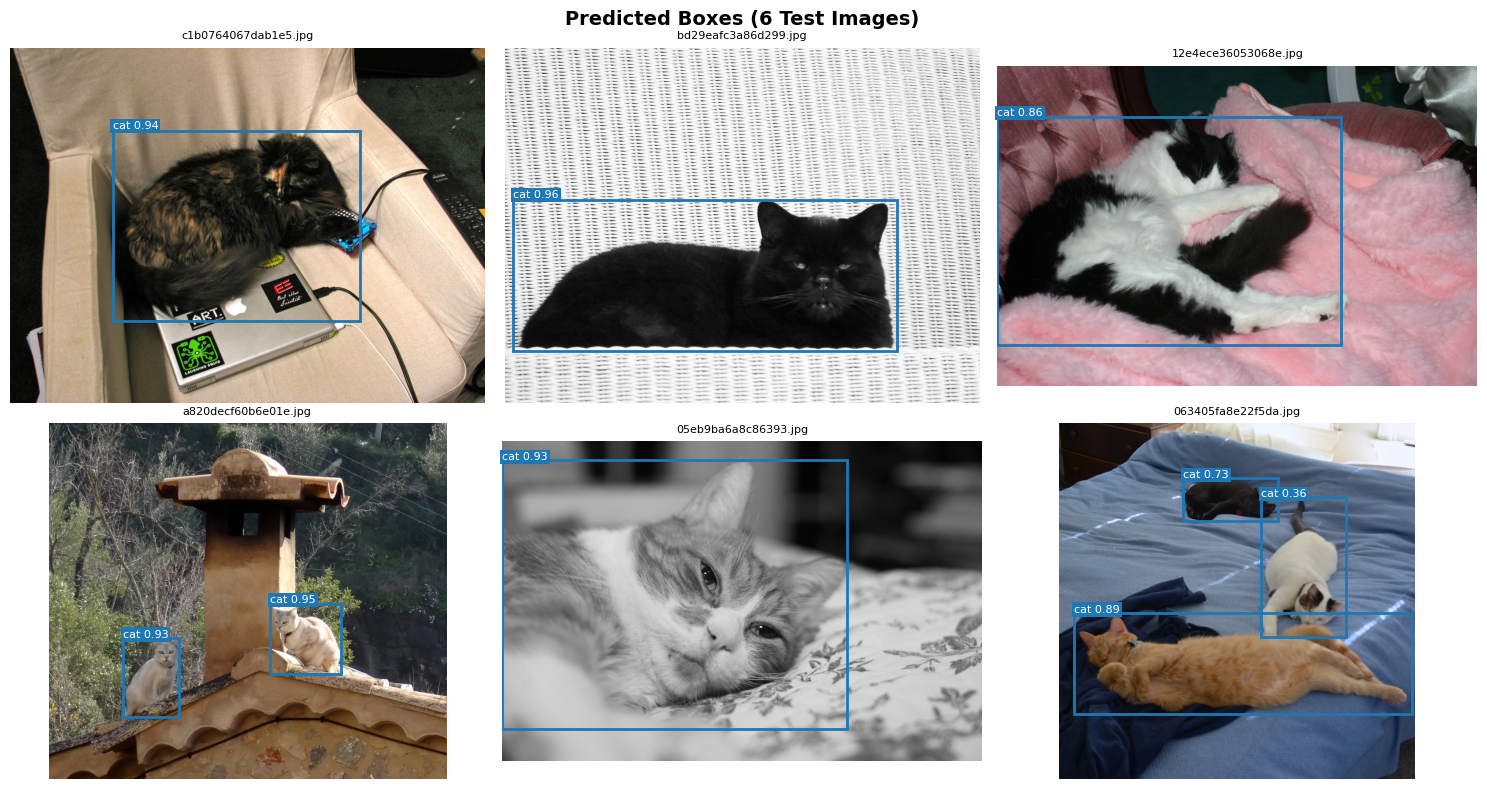

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

LABELS_DIR = "/content/drive/MyDrive/DATA_CLEAN/labels"
CLASS_NAMES = {0: "cat"}

results_pred = model.predict(source=sample6, conf=0.25, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Predicted Boxes (6 Test Images)", fontsize=14, fontweight="bold")

for ax, img_path, result in zip(axes.flatten(), sample6, results_pred):
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.split("/")[-1][:20], fontsize=8)

    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cid  = int(box.cls[0].item())
        color = plt.cm.tab10(cid % 10)
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1-4, f"{CLASS_NAMES.get(cid, cid)} {conf:.2f}",
                color="white", fontsize=8,
                bbox=dict(facecolor=color, edgecolor="none", pad=1.5))

plt.tight_layout()
plt.show()

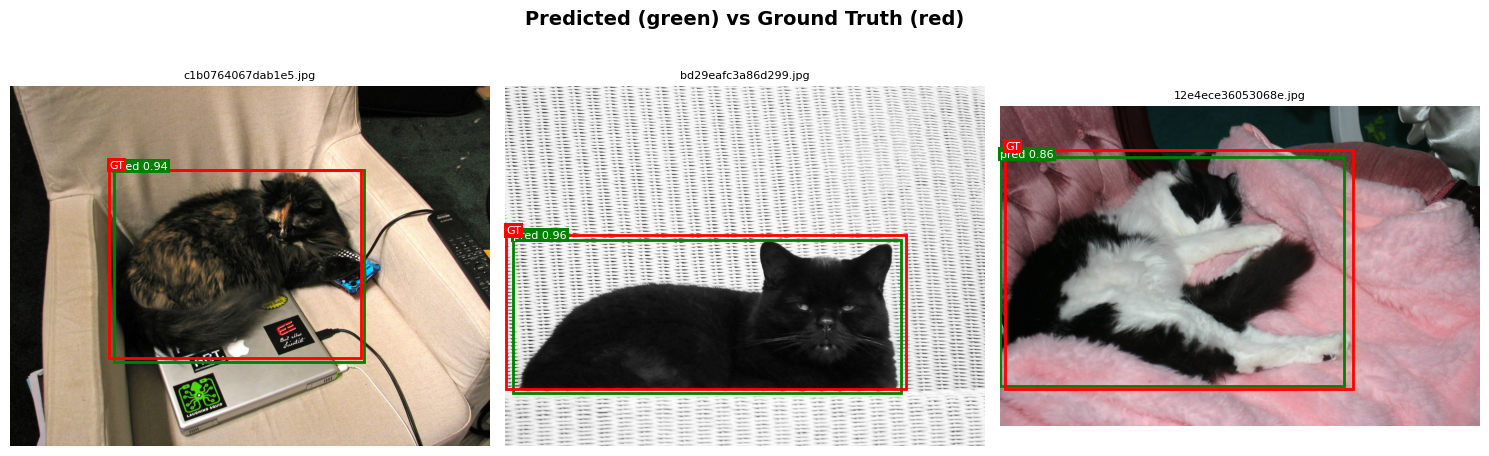

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Predicted (green) vs Ground Truth (red)", fontsize=14, fontweight="bold")

for ax, img_path, result in zip(axes, sample6[:3], results_pred[:3]):
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.split("/")[-1][:20], fontsize=8)


    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor="green", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1-4, f"pred {conf:.2f}", color="white", fontsize=8,
                bbox=dict(facecolor="green", edgecolor="none", pad=1.5))


    base = img_path.split("/")[-1].replace(".jpg", "")
    lbl_path = f"{LABELS_DIR}/{base}.txt"
    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cid, xc, yc, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = (xc - bw/2) * W
                y1 = (yc - bh/2) * H
                rect = patches.Rectangle((x1, y1), bw*W, bh*H,
                                           linewidth=2, edgecolor="red", facecolor="none")
                ax.add_patch(rect)
                ax.text(x1, y1-4, "GT", color="white", fontsize=8,
                        bbox=dict(facecolor="red", edgecolor="none", pad=1.5))

plt.tight_layout()
plt.show()

In [ ]:
failure_cases = []

for img_path in test_images:
    if len(failure_cases) >= 2:
        break

    base = img_path.split("/")[-1].replace(".jpg", "")
    lbl_path = f"{LABELS_DIR}/{base}.txt"
    if not os.path.exists(lbl_path):
        continue

    with open(lbl_path, "r") as f:
        gt_count = sum(1 for line in f if line.strip())

    result = model.predict(source=img_path, conf=0.25, verbose=False)[0]
    pred_count = len(result.boxes)

    if pred_count < gt_count:
        failure_cases.append(("FN", img_path, result, gt_count, pred_count))
    elif pred_count > gt_count:
        failure_cases.append(("FP", img_path, result, gt_count, pred_count))

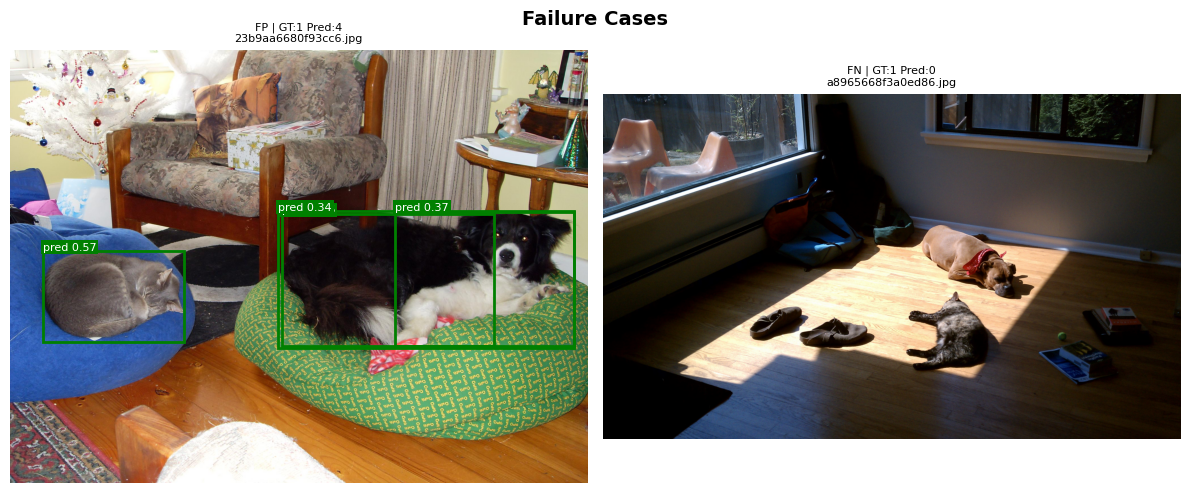

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Failure Cases", fontsize=14, fontweight="bold")

for ax, (ftype, img_path, result, gt_count, pred_count) in zip(axes, failure_cases):
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{ftype} | GT:{gt_count} Pred:{pred_count}\n{img_path.split('/')[-1][:20]}", fontsize=8)

    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor="green", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1-4, f"pred {conf:.2f}", color="white", fontsize=8,
                bbox=dict(facecolor="green", edgecolor="none", pad=1.5))

plt.tight_layout()
plt.show()

### Failure Case Analysis

**Image 1 — False Positive (FP): GT:1, Pred:4**
`23b9aa6680f93cc6.jpg`
The model correctly detected the cat (pred 0.57) but also fired 3 extra boxes
on the dog lying on the cushion. The dog's fur texture and curled posture likely
resembled a cat to the model, since the training set contains only cats and the
model has never learned to distinguish dogs.

**Image 2 — False Negative (FN): GT:1, Pred:0**
`a8965668f3a0ed86.jpg`
The model missed the cat entirely. The cat is lying in a dark shadowed area on
the floor, making it very low contrast against the background. The model likely
failed because the training set underrepresents cats in extreme lighting
conditions such as strong backlight or deep shadow.

### Task 6 — Reflection (Required, Brief)

In a final markdown cell, write 5–7 sentences answering:

- What did you learn about training a real object detector versus a classifier?
- What part of the dataset (or labels) caused the most trouble?
- Looking at the failure cases, what single change would you try next? (Bigger backbone? More augmentation? Cleaning a few mislabelled images?)
- One thing you'll do differently in next Friday's improvement assessment.


Training an object detector is significantly more complex than training a
classifier: instead of predicting a single label per image, the model must
simultaneously localise and classify multiple objects, which means the quality
of bounding box annotations matters as much as the images themselves.

The dataset was well-balanced with 3,327 matched image-label pairs and a single
class, which made preprocessing straightforward. However, some images contained
multiple animals where only one was annotated, which likely caused the model to
treat valid detections as false positives.

The failure cases revealed two distinct weaknesses: the model confuses dogs with
cats in cluttered scenes (false positives), and misses cats in low-contrast or
backlit conditions (false negatives).

The changes I would try next are: switching to a larger backbone (yolo26s)
for greater model capacity, training for more epochs (50–60) since the mAP
curve was still rising at epoch 30.